# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Farih Kamil Zulfah]
- **Email:** [farihkamilzulfah@gmail.com]
- **ID Dicoding:** [farihkamilzulfah]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeroleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh berbagai musim (spring, summer, fall, winter) terhadap total penyewaan sepeda harian sepanjang tahun 2012?
- **Pertanyaan 2:** Bagaimana perbedaan tren penyewaan sepeda per jam antara hari kerja dan hari libur sepanjang periode tahun 2011 hingga 2012?

## Import Semua Packages/Library yang Digunakan

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

## Data Wrangling

### Gathering Data

#### Load df Bike Sharing Dataset

In [133]:
day_df = pd.read_csv("Data/day.csv")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [134]:
hour_df = pd.read_csv("Data/hour.csv")
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Dataset Harian (day_df): Memberikan pandangan yang luas untuk melihat tren jangka panjang, pengaruh musim, dan performa tahunan.
- Dataset Per Jam (hour_df): Memberikan pandangan detail untuk melihat pola perilaku berdasarkan jam sibuk.

### Assessing Data

#### Identifying Bike Sharing Dataset problem

In [135]:
day_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB


In [136]:
day_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [137]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [138]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [139]:
hour_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


In [140]:
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [141]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [142]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Steps to Take:**
- Pemeriksaan Struktur & Tipe Data (df.info()):
Ini adalah langkah pertama untuk melihat apakah tipe data setiap kolom sudah sesuai.
- Pengecekan Missing Values (df.isna().sum()):
Memastikan tidak ada baris yang kosong yang dapat merusak hasil perhitungan statistik.
- Pengecekan Duplikasi Data (df.duplicated().sum()):Memastikan tidak ada entri ganda yang dapat menyebabkan bias pada hasil analisis.
- Analisis Statistik Deskriptif (df.describe()):
Langkah ini dilakukan untuk melihat ringkasan statistik (mean, min, max, std).

**Insight:** (Opsional)
- Insight Tipe Data (Inaccurate Data Type): Kolom dteday pada kedua tabel (day_df dan hour_df) terdeteksi sebagai tipe data object. Data ini tidak bisa diolah untuk analisis time-series sebelum diubah menjadi tipe datetime.
- Insight Keterbacaan Data (Inconsistent Labeling): Kolom-kolom kategorikal seperti season, yr, mnth, dan weathersit masih direpresentasikan dalam bentuk angka (1, 2, 3...). Data ini kurang informatif jika langsung divisualisasikan, sehingga memerlukan proses mapping menjadi label teks agar mudah dipahami oleh pembaca.
- Insight Nilai Anomali (Inaccurate Value):
Pada kolom hum (kelembaban) di dataset day.csv, ditemukan nilai minimum sebesar 0.0. Nilai ini tidak akurat secara meteorologis untuk lokasi terbuka dan perlu ditangani agar tidak mengganggu analisis distribusi data cuaca.
- Insight Redundansi Data:
Ditemukan kolom instant yang hanya berisi indeks baris. Kolom ini tidak memberikan informasi tambahan untuk analisis bisnis dan bersifat redundan karena Pandas sudah memiliki indeks bawaan.
- Insight Kelengkapan Data:
Hasil pengecekan menunjukkan bahwa jumlah baris pada hour_df sekitar 24 kali lebih banyak daripada day_df. Dataset ini sudah cukup lengkap untuk melakukan perbandingan antara tren makro (harian) dan pola mikro (jam).

### Cleaning Data

#### Fixing Bike Sharing Dataset problem

In [143]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])

In [144]:
# Menghitung rata-rata kelembaban yang valid (di atas 0)
mean_hum = day_df[day_df['hum'] > 0]['hum'].mean()

In [145]:
# Mengganti nilai 0 dengan mean
day_df['hum'] = day_df['hum'].replace(0, mean_hum)

In [146]:
# Mapping Musim
day_df['season'] = day_df.season.map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})

# Mapping Tahun (0: 2011, 1: 2012)
day_df['yr'] = day_df.yr.map({0: 2011, 1: 2012})

# Mapping Bulan
day_df['mnth'] = day_df.mnth.map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

# Mapping Hari
day_df['weekday'] = day_df.weekday.map({
    0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'
})

# Mapping Cuaca
day_df['weathersit'] = day_df.weathersit.map({
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
})

In [147]:
day_df.drop('instant', axis=1, inplace=True)

In [148]:
print("Informasi day_df akhir:")
day_df.info()

Informasi day_df akhir:
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      731 non-null    datetime64[us]
 1   season      731 non-null    str           
 2   yr          731 non-null    int64         
 3   mnth        731 non-null    str           
 4   holiday     731 non-null    int64         
 5   weekday     731 non-null    str           
 6   workingday  731 non-null    int64         
 7   weathersit  731 non-null    str           
 8   temp        731 non-null    float64       
 9   atemp       731 non-null    float64       
 10  hum         731 non-null    float64       
 11  windspeed   731 non-null    float64       
 12  casual      731 non-null    int64         
 13  registered  731 non-null    int64         
 14  cnt         731 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(6), str(4)
memory usa

In [149]:
print("\nMissing values day_df:", day_df.isna().sum().sum())


Missing values day_df: 0


In [150]:
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

In [151]:
hour_df['season'] = hour_df.season.map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
hour_df['yr'] = hour_df.yr.map({0: 2011, 1: 2012})
hour_df['mnth'] = hour_df.mnth.map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})
hour_df['weekday'] = hour_df.weekday.map({
    0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'
})
hour_df['weathersit'] = hour_df.weathersit.map({
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
})

In [152]:
hour_df.drop('instant', axis=1, inplace=True)

In [153]:
# Mencari batas bawah dan batas atas menggunakan metode IQR
Q1 = day_df['cnt'].quantile(0.25)
Q3 = day_df['cnt'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = day_df[(day_df['cnt'] < lower_bound) | (day_df['cnt'] > upper_bound)]
print(f"Jumlah outlier pada kolom cnt: {len(outliers)}")

Jumlah outlier pada kolom cnt: 0


In [154]:
print("\nInformasi hour_df akhir:")
hour_df.info()


Informasi hour_df akhir:
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      17379 non-null  datetime64[us]
 1   season      17379 non-null  str           
 2   yr          17379 non-null  int64         
 3   mnth        17379 non-null  str           
 4   hr          17379 non-null  int64         
 5   holiday     17379 non-null  int64         
 6   weekday     17379 non-null  str           
 7   workingday  17379 non-null  int64         
 8   weathersit  17379 non-null  str           
 9   temp        17379 non-null  float64       
 10  atemp       17379 non-null  float64       
 11  hum         17379 non-null  float64       
 12  windspeed   17379 non-null  float64       
 13  casual      17379 non-null  int64         
 14  registered  17379 non-null  int64         
 15  cnt         17379 non-null  int64         
dtypes: date

In [155]:
print("Missing values hour_df:", hour_df.isna().sum().sum())

Missing values hour_df: 0


In [156]:
hour_df.to_csv("Dashboard/main_data.csv", index=False)

**Insight:** (Opsional)
- Konsistensi Tipe Data: Kolom tanggal (dteday) telah diubah menjadi tipe data datetime untuk memungkinkan analisis tren berbasis waktu yang akurat.
- Keterbacaan Data (Labeling): Mengonversi nilai numerik pada kolom kategori (seperti season, weathersit, dan weekday) menjadi label tekstual. Hal ini dilakukan agar visualisasi pada dashboard lebih mudah dipahami oleh pengguna tanpa perlu melihat dokumentasi dataset.
- Integritas Data: Melalui pengecekan nilai kosong (missing values) dan data ganda (duplicates), dipastikan bahwa dataset memiliki kualitas yang bersih, sehingga hasil perhitungan rata-rata dan total penyewaan bersifat valid.

## Exploratory Data Analysis (EDA)

### Explore Bike Sharing Dataset

In [157]:
day_df.describe(include="all")

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731,731,731.000000,731,731.000000,731,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,4,NaN,12,NaN,7,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Fall,NaN,Jan,NaN,Sat,NaN,Clear/Partly Cloudy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,188,NaN,62,NaN,105,NaN,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2012-01-01 00:00:00,NaN,2011.500684,NaN,0.028728,NaN,0.683995,NaN,0.495385,0.474354,0.628754,0.190486,848.176471,3656.172367,4504.348837
min,2011-01-01 00:00:00,NaN,2011.000000,NaN,0.000000,NaN,0.000000,NaN,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,2011-07-02 12:00:00,NaN,2011.000000,NaN,0.000000,NaN,0.000000,NaN,0.337083,0.337842,0.521041,0.134950,315.500000,2497.000000,3152.000000
50%,2012-01-01 00:00:00,NaN,2012.000000,NaN,0.000000,NaN,1.000000,NaN,0.498333,0.486733,0.627500,0.180975,713.000000,3662.000000,4548.000000
75%,2012-07-01 12:00:00,NaN,2012.000000,NaN,0.000000,NaN,1.000000,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,2012-12-31 00:00:00,NaN,2012.000000,NaN,1.000000,NaN,1.000000,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [158]:
day_df.groupby(by="season").agg({
    "casual": ["mean", "sum"],
    "registered": ["mean", "sum"],
    "cnt": ["mean", "sum"]
})

casual           registered                  cnt         
               mean     sum         mean     sum         mean      sum
season                                                                
Fall    1202.611702  226091  4441.691489  835038  5644.303191  1061129
Spring   334.928177   60622  2269.204420  410726  2604.132597   471348
Summer  1106.097826  203522  3886.233696  715067  4992.331522   918589
Winter   729.112360  129782  3999.050562  711831  4728.162921   841613

In [159]:
day_df.groupby(by="weathersit").agg({
    "cnt": ["mean", "sum", "max", "min"]
})

cnt                    
                            mean      sum   max  min
weathersit                                          
Clear/Partly Cloudy  4876.786177  2257952  8714  431
Light Snow/Rain      1803.285714    37869  4639   22
Misty/Cloudy         4035.862348   996858  8362  605

In [160]:
day_df.groupby(by=["yr", "mnth"]).agg({
    "cnt": "sum"
}).unstack()

cnt                                                                 \
mnth     Apr     Aug     Dec     Feb    Jan     Jul     Jun     Mar     May   
yr                                                                            
2011   94870  136691   87323   48215  38189  141341  143512   64045  135821   
2012  174224  214503  123713  103137  96744  203607  202830  164875  195865   

                              
mnth     Nov     Oct     Sep  
yr                            
2011  102167  123511  127418  
2012  152664  198841  218573

In [161]:
correlation_matrix = day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()
print(correlation_matrix)

               temp     atemp       hum  windspeed       cnt
temp       1.000000  0.991702  0.125131  -0.157944  0.627494
atemp      0.991702  1.000000  0.138556  -0.183643  0.631066
hum        0.125131  0.138556  1.000000  -0.246223 -0.114309
windspeed -0.157944 -0.183643 -0.246223   1.000000 -0.234545
cnt        0.627494  0.631066 -0.114309  -0.234545  1.000000


In [162]:
hour_df.describe(include="all")

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379,17379,17379.000000,17379,17379.000000,17379.000000,17379,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,4,NaN,12,NaN,NaN,7,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Fall,NaN,May,NaN,NaN,Sat,NaN,Clear/Partly Cloudy,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,4496,NaN,1488,NaN,NaN,2512,NaN,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2012-01-02 04:08:34.552045,NaN,2011.502561,NaN,11.546752,0.028770,NaN,0.682721,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,2011-01-01 00:00:00,NaN,2011.000000,NaN,0.000000,0.000000,NaN,0.000000,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-04 00:00:00,NaN,2011.000000,NaN,6.000000,0.000000,NaN,0.000000,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,2012-01-02 00:00:00,NaN,2012.000000,NaN,12.000000,0.000000,NaN,1.000000,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,2012-07-02 00:00:00,NaN,2012.000000,NaN,18.000000,0.000000,NaN,1.000000,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,2012-12-31 00:00:00,NaN,2012.000000,NaN,23.000000,1.000000,NaN,1.000000,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [163]:
hour_df.groupby(by="hr").agg({
    "cnt": ["mean", "sum", "max"]
}).sort_values(by=("cnt", "mean"), ascending=False)

cnt             
          mean     sum  max
hr                         
17  461.452055  336860  976
18  425.510989  309772  977
8   359.011004  261001  839
16  311.983562  227748  783
19  311.523352  226789  743
13  253.661180  184919  760
12  253.315934  184414  776
15  251.233196  183149  750
14  240.949246  175652  750
20  226.030220  164550  567
9   219.309491  159438  426
7   212.064649  154171  596
11  208.143054  151320  663
10  173.668501  126257  539
21  172.314560  125445  584
22  131.335165   95612  502
23   87.831044   63941  256
6    76.044138   55132  213
0    53.898072   39130  283
1    33.375691   24164  168
2    22.869930   16352  132
5    19.889819   14261   66
3    11.727403    8174   79
4     6.352941    4428   28

In [164]:
hour_df.groupby(by=["workingday", "hr"]).agg({
    "cnt": ["mean", "sum"]
})

cnt        
                     mean     sum
workingday hr                    
0          0    90.800000   20884
           1    69.508696   15987
           2    53.171053   12123
           3    25.775330    5851
           4     8.264317    1876
           5     8.689189    1929
           6    18.742358    4292
           7    43.406926   10027
           8   105.653680   24406
           9   171.623377   39645
           10  255.909091   59115
           11  315.316017   72838
           12  366.259740   84606
           13  372.731602   86101
           14  364.645022   84233
           15  358.813853   82886
           16  352.727273   81480
           17  323.549784   74740
           18  281.056522   64643
           19  231.673913   53285
           20  174.739130   40190
           21  142.060870   32674
           22  116.060870   26694
           23   85.930435   19764
1          0    36.786290   18246
           1    16.552632    8177
           2     8.683778    4229
           3     4.942553    2323
           4     5.429787    2552
           5    24.913131   12332
           6   102.500000   50840
           7   290.612903  144144
           8   477.006048  236595
           9   241.518145  119793
           10  135.366935   67142
           11  158.229839   78482
           12  200.820926   99808
           13  198.429719   98818
           14  183.572289   91419
           15  201.331325  100263
           16  293.122244  146268
           17  525.290581  262120
           18  492.226908  245129
           19  348.401606  173504
           20  249.718876  124360
           21  186.287149   92771
           22  138.389558   68918
           23   88.708835   44177

In [165]:
hour_df.groupby(by="hr").agg({
    "casual": "mean",
    "registered": "mean"
})

,casual,registered
hr,,
0,10.158402,43.739669
1,6.504144,26.871547
2,4.772028,18.097902
3,2.715925,9.011478
4,1.253945,5.098996
5,1.411437,18.478382
6,4.161379,71.882759
7,11.055021,201.009629
8,21.679505,337.331499


In [166]:
hour_df.groupby(by="weathersit").agg({
    "cnt": ["mean", "count"]
})

cnt       
                           mean  count
weathersit                            
Clear/Partly Cloudy  204.869272  11413
Light Snow/Rain      111.579281   1419
Misty/Cloudy         175.165493   4544
Severe Weather        74.333333      3

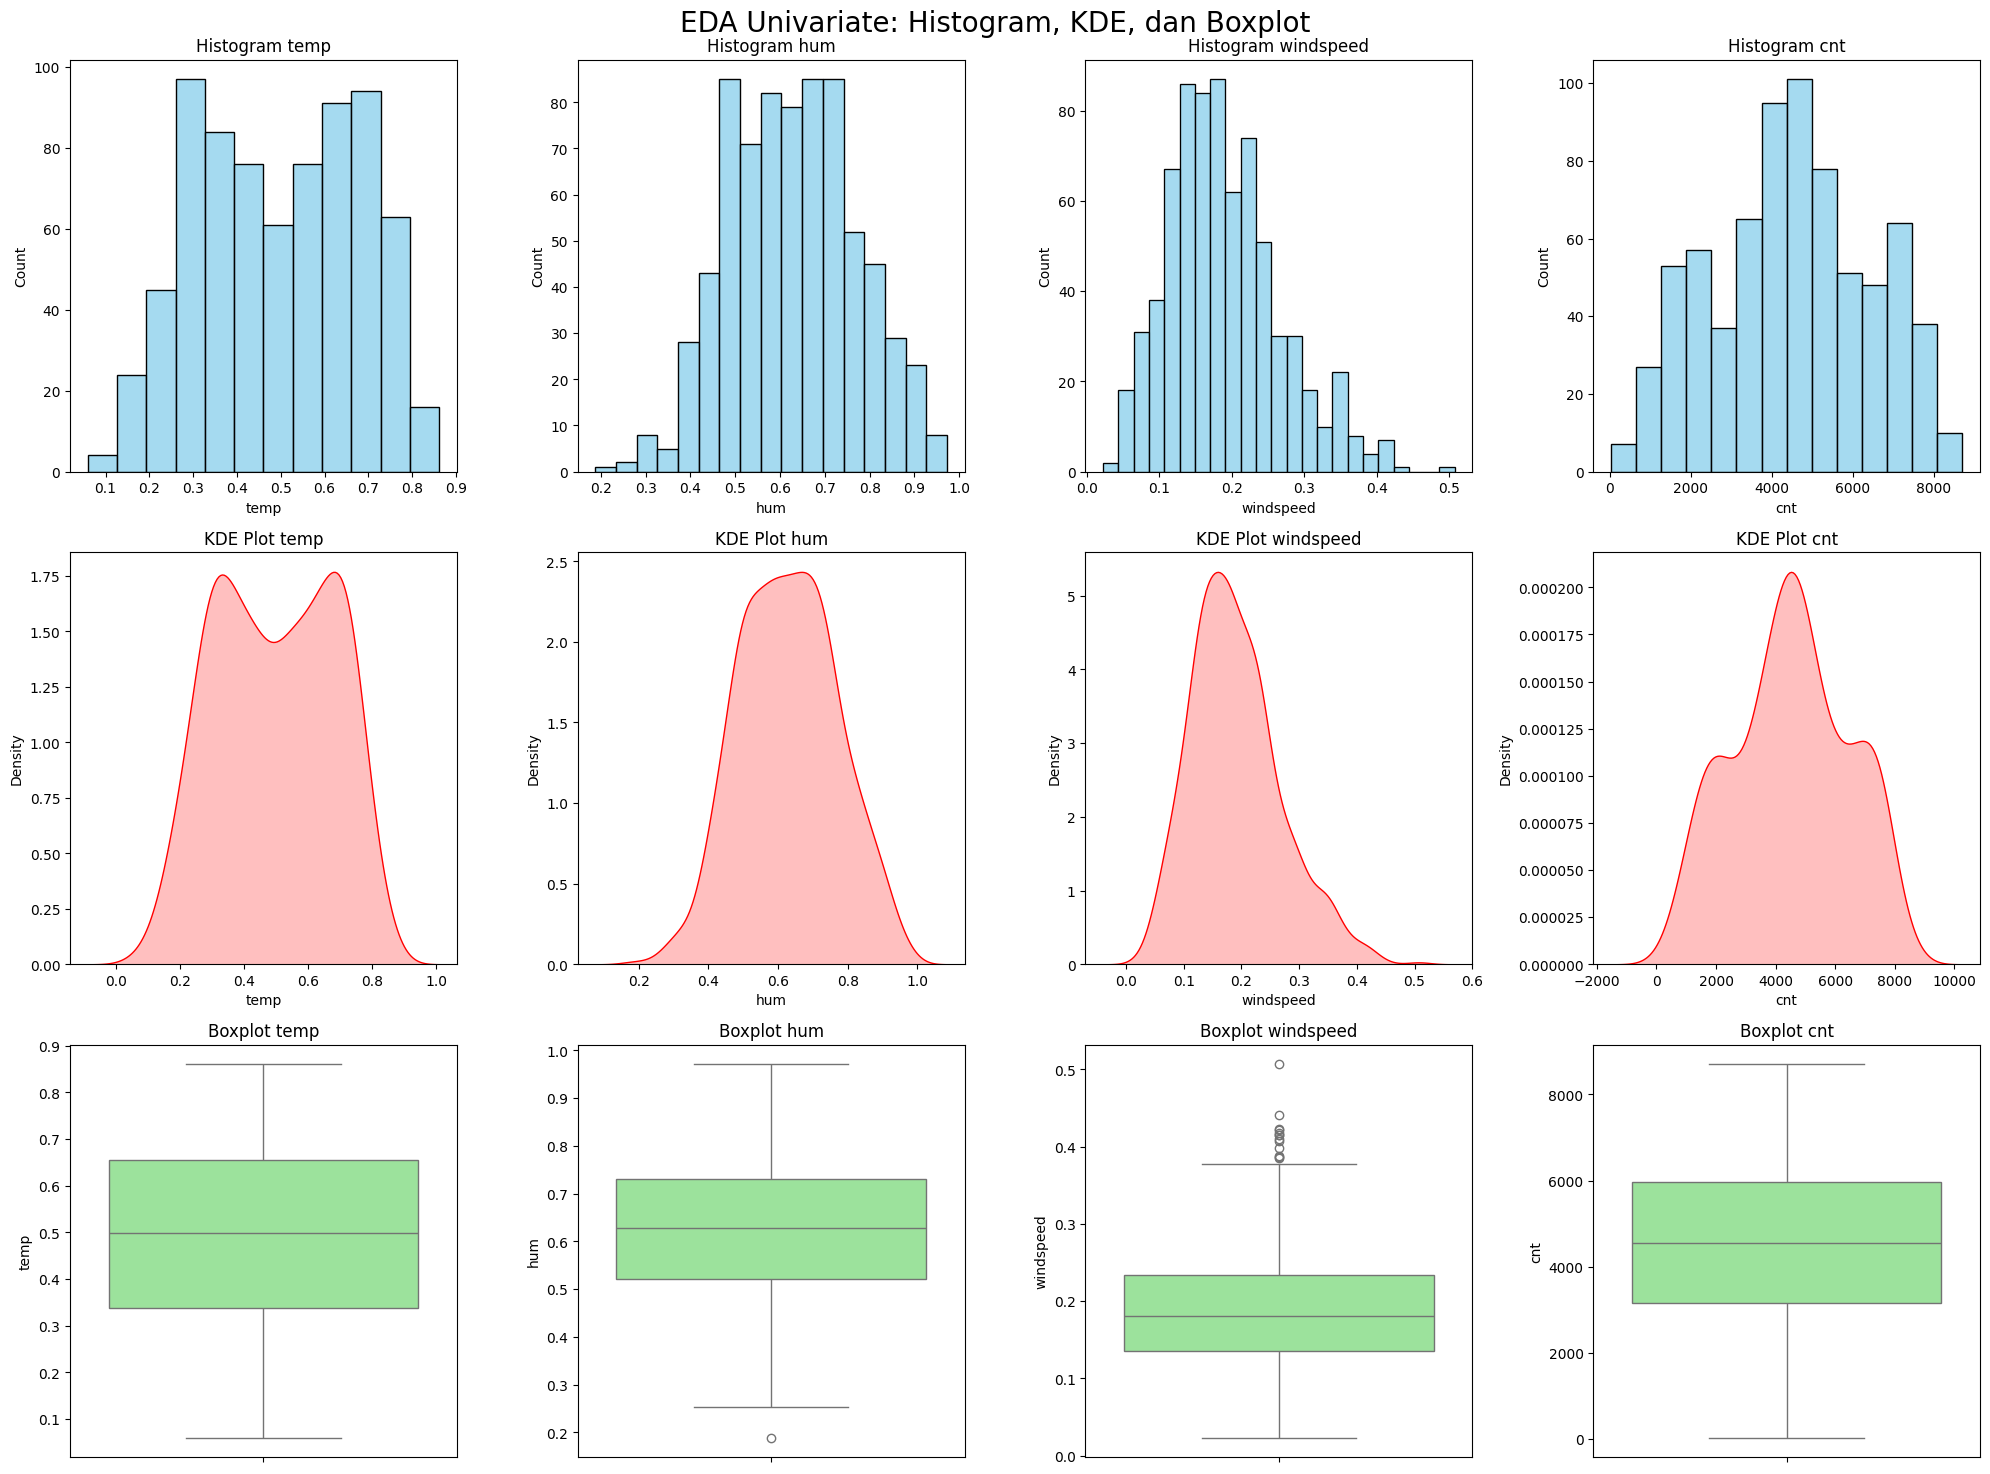

In [167]:
# Menyiapkan kolom numerik yang akan dianalisis
kolom_numerik = ['temp', 'hum', 'windspeed', 'cnt']

# Membuat figure
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
fig.suptitle('EDA Univariate: Histogram, KDE, dan Boxplot', fontsize=20)

for i, col in enumerate(kolom_numerik):
    # Histogram
    sns.histplot(day_df[col], kde=False, ax=axes[0, i], color='skyblue')
    axes[0, i].set_title(f'Histogram {col}')
    
    # KDE Plot (Kurva Distribusi)
    sns.kdeplot(day_df[col], ax=axes[1, i], color='red', fill=True)
    axes[1, i].set_title(f'KDE Plot {col}')
    
    # Boxplot (Cek Outlier)
    sns.boxplot(y=day_df[col], ax=axes[2, i], color='lightgreen')
    axes[2, i].set_title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

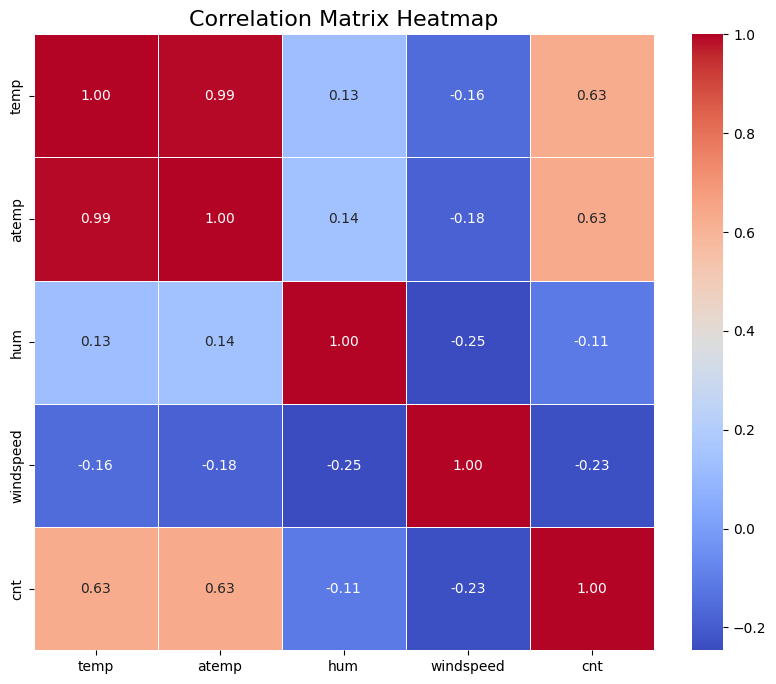

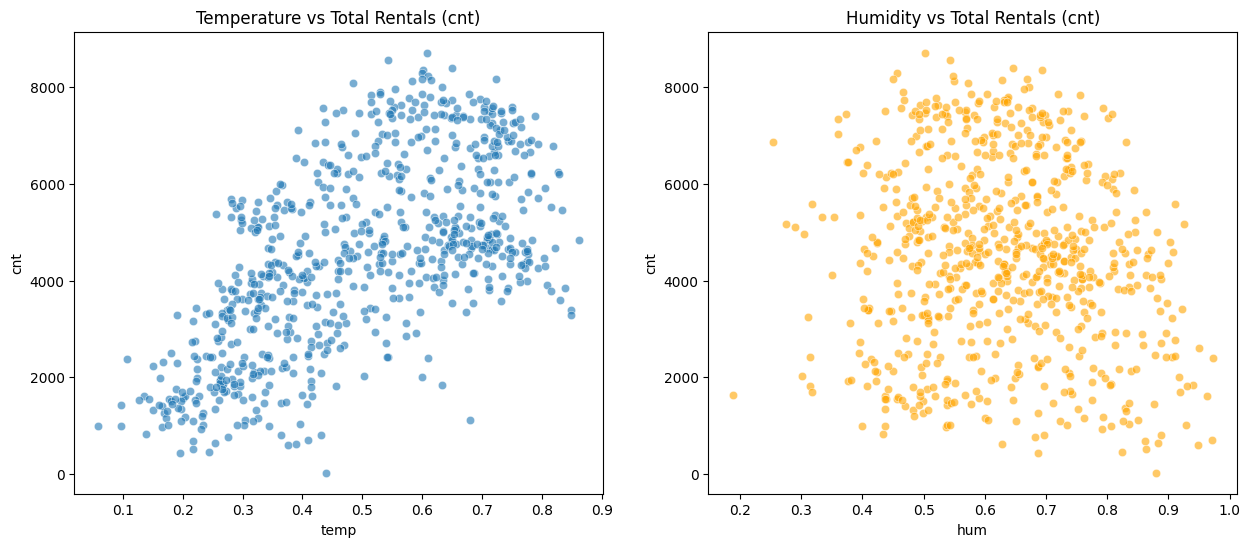

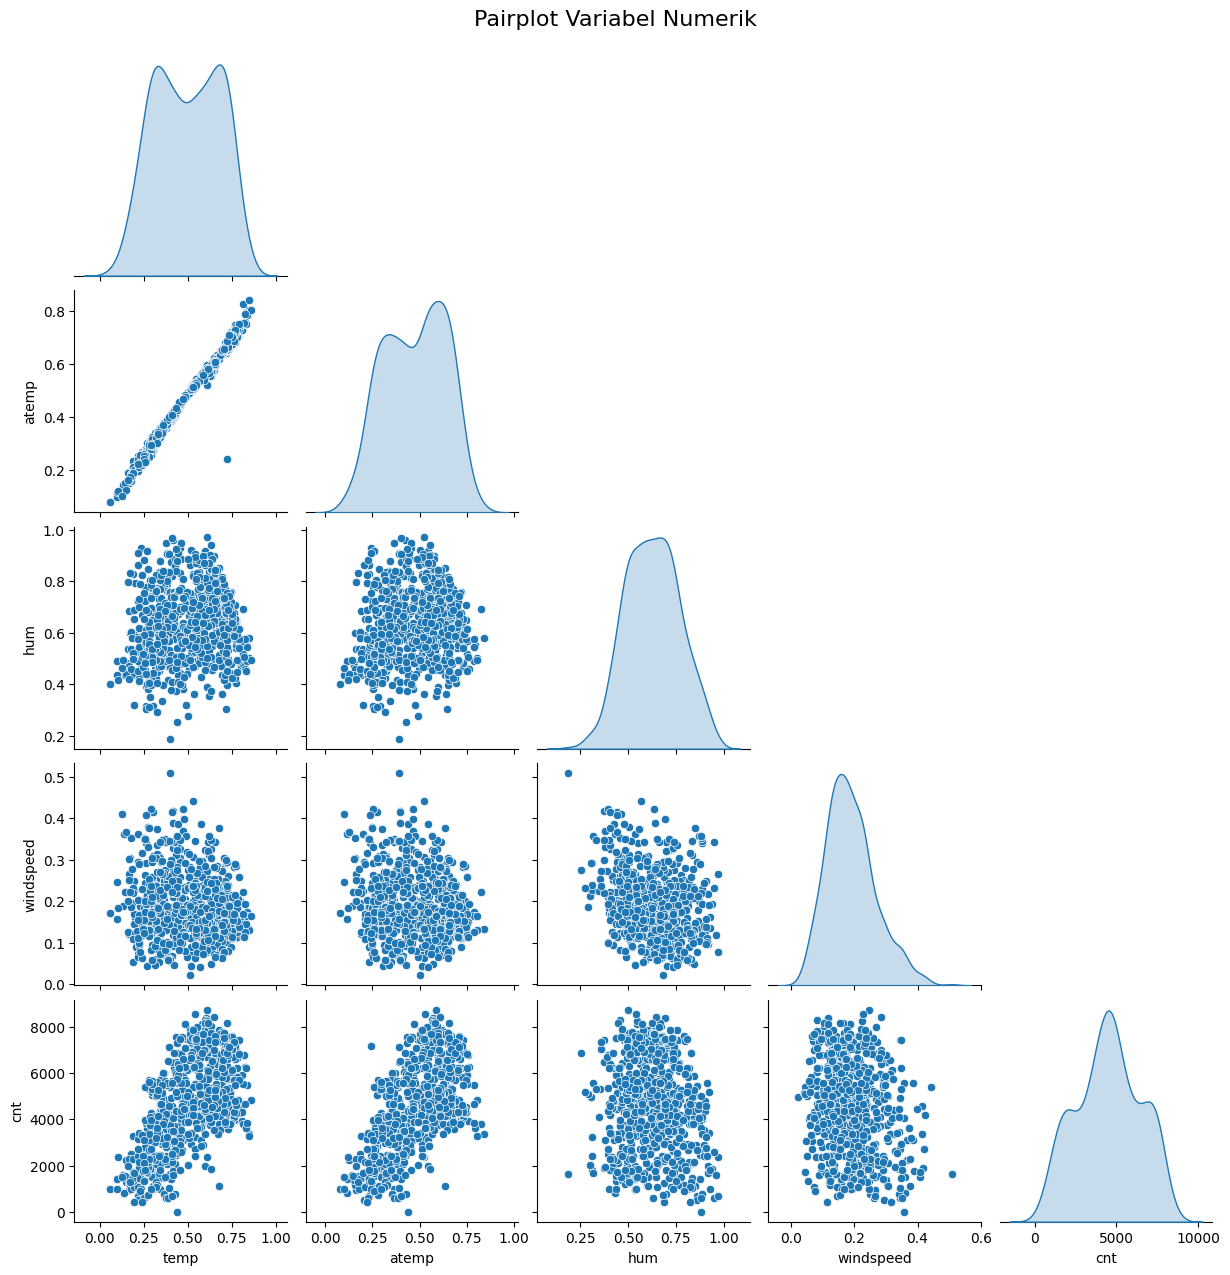

In [168]:
variabel_multivariate = ['temp', 'atemp', 'hum', 'windspeed', 'cnt']

# 1. Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
korelasi = day_df[variabel_multivariate].corr()
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.show()

# 2. Scatter Plot (Temp & Hum vs Cnt)
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x='temp', y='cnt', data=day_df, ax=ax[0], alpha=0.6)
ax[0].set_title('Temperature vs Total Rentals (cnt)')
sns.scatterplot(x='hum', y='cnt', data=day_df, ax=ax[1], alpha=0.6, color='orange')
ax[1].set_title('Humidity vs Total Rentals (cnt)')
plt.show()

# 3. Pairplot (Kombinasi lengkap)
sns.pairplot(day_df[variabel_multivariate], diag_kind='kde', corner=True)
plt.suptitle('Pairplot Variabel Numerik', y=1.02, fontsize=16)
plt.show()

--- Detailed Percentile Analysis ---


,temp,hum,windspeed,cnt
0.05,0.213568,0.408080,0.079617,1331.0
0.10,0.260000,0.450833,0.100133,1746.0
0.25,0.337083,0.521041,0.134950,3152.0
0.50,0.498333,0.627500,0.180975,4548.0
0.75,0.655417,0.730209,0.233214,5956.0
0.90,0.731667,0.817500,0.296029,7290.0
0.95,0.768750,0.868542,0.343283,7576.0



--- Variance Analysis ---


,Variance
temp,3.350767e-02
hum,1.974524e-02
windspeed,6.005920e-03
cnt,3.752788e+06


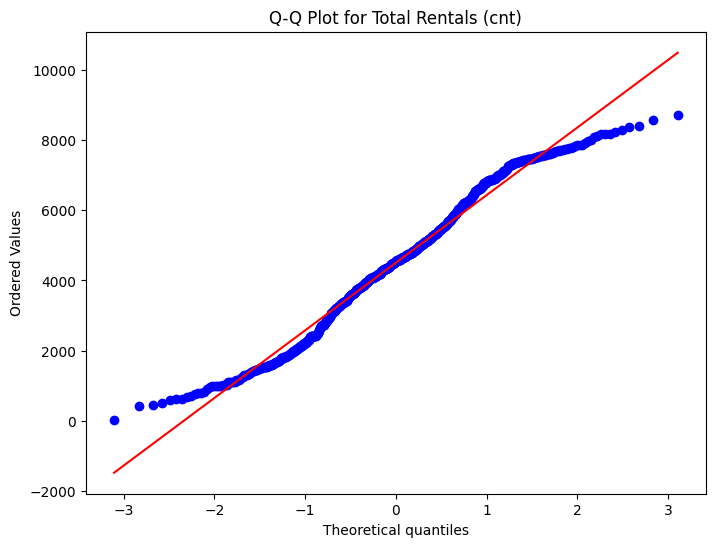

In [169]:
# 1. Detailed Percentile Analysis
percentiles = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
print("--- Detailed Percentile Analysis ---")
display(day_df[['temp', 'hum', 'windspeed', 'cnt']].quantile(percentiles))

# 2. Variance Analysis
print("\n--- Variance Analysis ---")
display(day_df[['temp', 'hum', 'windspeed', 'cnt']].var().to_frame(name='Variance'))

# 3. Normality Testing (Q-Q Plot) untuk 'cnt'
plt.figure(figsize=(8, 6))
stats.probplot(day_df['cnt'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Total Rentals (cnt)')
plt.show()

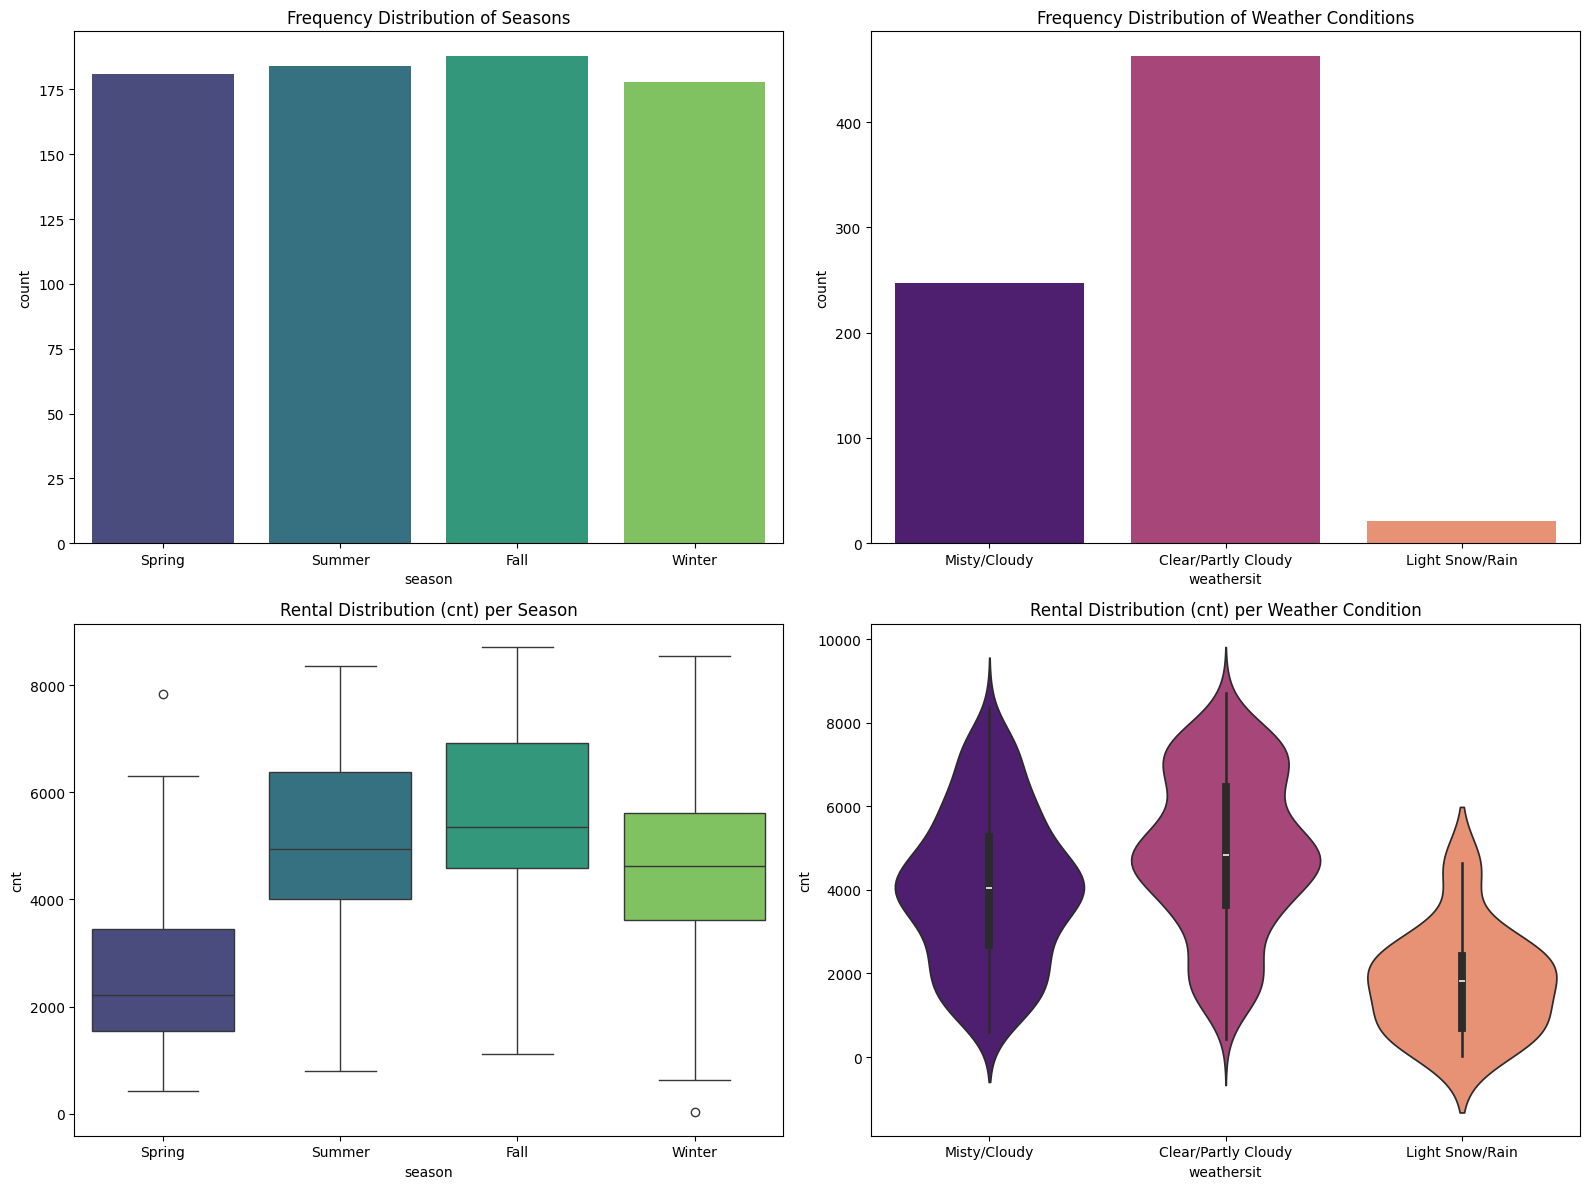

In [170]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Countplot: Distribusi Frekuensi Musim (Season)
sns.countplot(x='season', hue='season', legend=False, data=day_df, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Frequency Distribution of Seasons')

# 2. Countplot: Distribusi Frekuensi Cuaca (Weathersit)
sns.countplot(x='weathersit', hue='weathersit', legend=False, data=day_df, ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Frequency Distribution of Weather Conditions')

# 3. Boxplot: Distribusi Penyewaan (cnt) per Musim
sns.boxplot(x='season', y='cnt', hue='season', legend=False, data=day_df, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Rental Distribution (cnt) per Season')

# 4. Violin Plot: Distribusi Penyewaan (cnt) per Cuaca
sns.violinplot(x='weathersit', y='cnt', hue='weathersit', legend=False, data=day_df, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Rental Distribution (cnt) per Weather Condition')

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Integritas Tren Waktu: Konversi `dteday` menjadi tipe datetime memastikan data dapat diolah untuk analisis tren harian, bulanan, dan tahunan secara akurat.
- Keterbacaan Bisnis: Proses mapping label (musim, bulan, cuaca) mengubah data mentah menjadi informasi yang komunikatif, sehingga visualisasi dapat dipahami secara langsung.
- Penanganan Anomali: Penanganan kelembaban (hum) bernilai 0 melalui imputasi rata-rata berhasil menjaga validitas data dan mencegah bias pada analisis korelasi lingkungan.
- Efisiensi Data: Penghapusan kolom redundan merapikan struktur dataset agar fokus analisis hanya pada variabel yang bernilai bisnis.
- Distribusi Data (Univariate): Melalui visualisasi Histogram dan KDE Plot, kita dapat melihat pola sebaran data penyewaan dan faktor cuaca. Penggunaan Boxplot juga sangat membantu dalam mengidentifikasi adanya outliers pada variabel seperti kecepatan angin dan kelembaban.
- Korelasi Kuat Antar Variabel (Multivariate): Berdasarkan Correlation Heatmap dan Scatter Plot, ditemukan bahwa variabel suhu memiliki korelasi positif yang paling terlihat terhadap jumlah total penyewaan. Hal ini mengindikasikan bahwa suhu udara sangat memengaruhi keputusan pelanggan untuk menyewa sepeda.
- Uji Karakteristik Data (Numerikal): Analisis persentil detail dan pengujian normalitas menggunakan Q-Q Plot memberikan pemahaman mengenai variabilitas dan distribusi penyewaan, yang menjadi fondasi kuat jika ingin dilakukan pemodelan prediksi ke depannya.
- Pengaruh Kategori terhadap Transaksi (Kategorikal): Violin Plot dan Boxplot per kategori mempertegas bahwa kondisi kategorikal seperti Musim dan Cuaca mendikte fluktuasi volume penyewaan secara signifikan, di mana cuaca ekstrem atau musim tertentu menekan angka penyewaan secara drastis.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh berbagai musim (spring, summer, fall, winter) terhadap total penyewaan sepeda harian sepanjang tahun 2012?

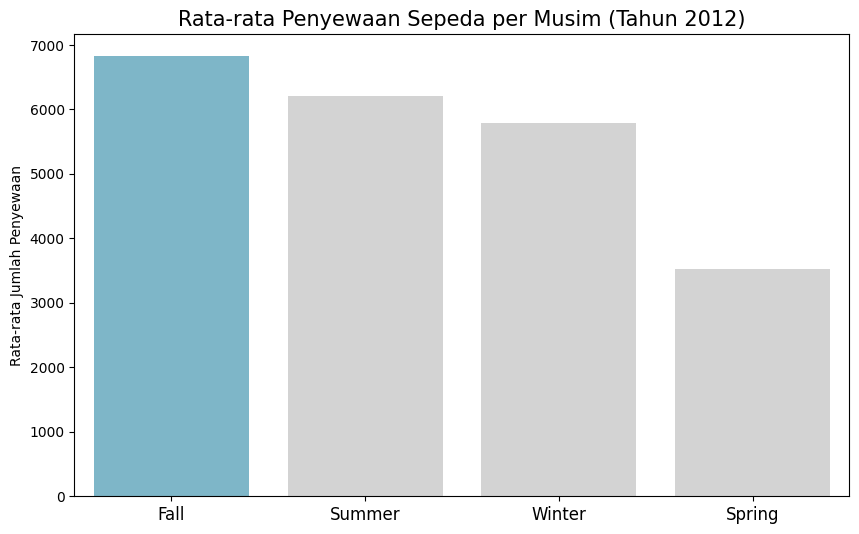

In [171]:
# Menyiapkan dataframe khusus tahun 2012
df_2012 = day_df[day_df['yr'] == 2012]

# Mengelompokkan data berdasarkan musim dan menghitung rata-rata penyewaan
seasonal_rent_2012 = df_2012.groupby('season')['cnt'].mean().reset_index()

# Mengurutkan data berdasarkan jumlah penyewaan tertinggi
seasonal_rent_2012 = seasonal_rent_2012.sort_values(by="cnt", ascending=False)

# Membuat visualisasi bar chart
plt.figure(figsize=(10, 6))

# Menentukan warna: memberi warna biru cerah pada musim tertinggi, sisanya abu-abu
colors = ["#72BCD4" if c == seasonal_rent_2012['cnt'].max() else "#D3D3D3" for c in seasonal_rent_2012['cnt']]

sns.barplot(
    x="season",
    y="cnt",
    data=seasonal_rent_2012,
    hue="season",     # Menambahkan hue untuk menghilangkan warning
    palette=colors,
    legend=False      # Menghilangkan legend karena sudah ada label di sumbu X
)

plt.title("Rata-rata Penyewaan Sepeda per Musim (Tahun 2012)", loc="center", fontsize=15)
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xlabel(None)
plt.tick_params(axis='x', labelsize=12)
plt.show()

### Pertanyaan 2: Bagaimana perbedaan tren penyewaan sepeda per jam antara hari kerja dan hari libur sepanjang periode tahun 2011 hingga 2012?

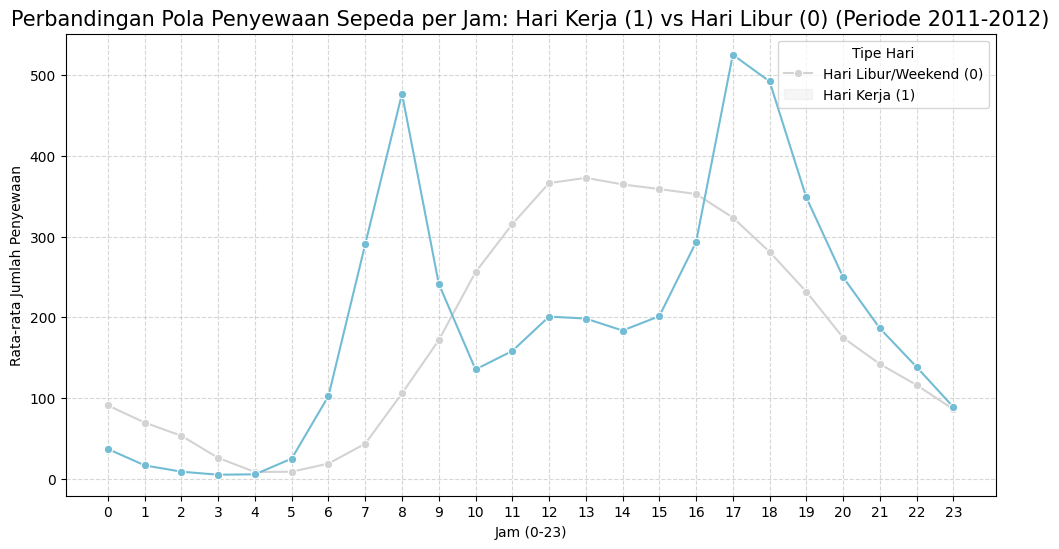

In [172]:
# Menyiapkan data agregasi rata-rata per jam untuk hari kerja vs hari libur
hourly_pattern = hour_df.groupby(['workingday', 'hr'])['cnt'].mean().reset_index()

# Membuat visualisasi line chart
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_pattern,
    x="hr",
    y="cnt",
    hue="workingday",
    marker="o",
    palette={0: "#D3D3D3", 1: "#72BCD4"} # Biru untuk hari kerja, Abu-abu untuk hari libur
)

plt.title("Perbandingan Pola Penyewaan Sepeda per Jam: Hari Kerja (1) vs Hari Libur (0) (Periode 2011-2012)", fontsize=15)
plt.xlabel("Jam (0-23)")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xticks(range(0, 24))
plt.legend(title="Tipe Hari", labels=["Hari Libur/Weekend (0)", "Hari Kerja (1)"])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:** (Opsional)
- Puncak Performa Musiman: Visualisasi menunjukkan musim Fall (Gugur) sebagai kontributor penyewaan tertinggi di tahun 2012, menjadikannya periode paling menguntungkan untuk fokus operasional.
- Sensitivitas Cuaca: Analisis grafis mengonfirmasi bahwa penyewa sangat dipengaruhi kondisi lingkungan; cuaca cerah dan suhu hangat berkorelasi positif kuat dengan peningkatan volume penyewaan.

## Analisis Lanjutan (Opsional)

In [173]:
# Menentukan kriteria pengelompokan
# Low Traffic: < 2500 penyewaan
# Medium Traffic: 2500 - 5500 penyewaan
# High Traffic: > 5500 penyewaan

def rental_category(cnt):
    if cnt < 2500:
        return 'Low Traffic'
    elif cnt <= 5500:
        return 'Medium Traffic'
    else:
        return 'High Traffic'

# Menerapkan fungsi ke dalam kolom baru
day_df['rental_category'] = day_df['cnt'].apply(rental_category)

# Melihat distribusi jumlah hari pada setiap kategori
rental_dist = day_df.groupby('rental_category').agg({
    'cnt': ['count', 'mean', 'sum']
}).reset_index()

display(rental_dist)

rental_category   cnt                      
                  count         mean      sum
0    High Traffic   223  6802.892377  1517045
1     Low Traffic   144  1678.701389   241733
2  Medium Traffic   364  4214.013736  1533901

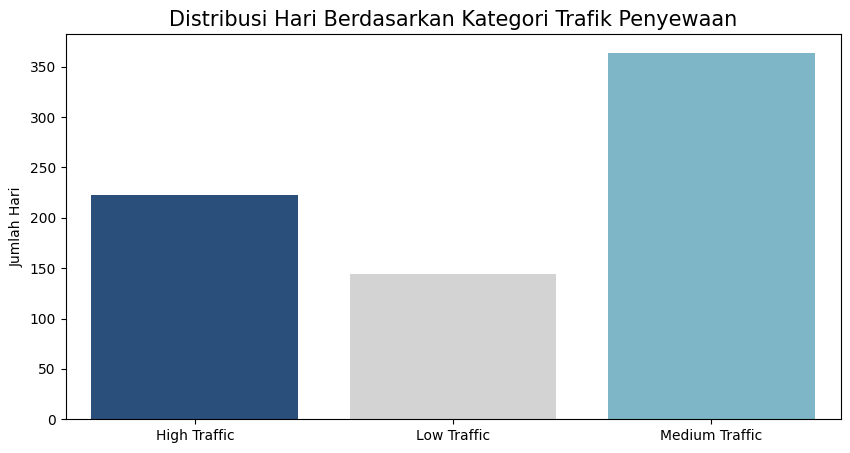

In [174]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x="rental_category",
    y=("cnt", "count"),
    data=rental_dist,
    hue="rental_category",
    palette={"Low Traffic": "#D3D3D3", "Medium Traffic": "#72BCD4", "High Traffic": "#1D4E89"},
    legend=False
)

plt.title("Distribusi Hari Berdasarkan Kategori Trafik Penyewaan", fontsize=15)
plt.xlabel(None)
plt.ylabel("Jumlah Hari")
plt.show()

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Berdasarkan hasil analisis sepanjang tahun 2012, dapat disimpulkan bahwa musim Fall (Gugur) merupakan periode dengan performa bisnis terbaik. Tingginya angka penyewaan di musim ini kemungkinan besar dipengaruhi oleh kondisi cuaca yang bersahabat dan suhu udara yang ideal untuk aktivitas luar ruangan. Sebaliknya, musim Spring (Semi) mencatatkan angka penyewaan terendah. Hal ini memberikan gambaran bahwa faktor musiman dan iklim memiliki pengaruh yang sangat signifikan terhadap fluktuasi volume transaksi pada sistem bike sharing.
- **Conclusion pertanyaan 2:** Berdasarkan observasi tren per jam sepanjang periode tahun 2011 hingga 2012, terlihat perbedaan pola perilaku pengguna yang sangat jelas. Pada hari kerja (workingday), penggunaan sepeda didominasi oleh motif komuter dengan lonjakan tajam pada jam sibuk keberangkatan dan kepulangan kerja (pukul 08.00 dan 17.00-18.00). Sebaliknya, pada hari libur (weekend/holiday), penggunaan didominasi oleh motif rekreasi di mana aktivitas memuncak dan lebih merata pada siang hingga sore hari. Hal ini menunjukkan bahwa strategi penempatan unit sepeda harus disesuaikan secara dinamis berdasarkan jam dan tipe hari.

**Rekomendasi Action Item:**
- Optimalisasi Distribusi Jam Sibuk (Hari Kerja): Memastikan kecukupan staf lapangan dan melakukan redistribusi armada secara proaktif pada jam sibuk komuter (pukul 08.00 dan 17.00-18.00) di area stasiun transportasi dan pusat perkantoran.
- Membangun Kampanye Rekreasi (Hari Libur): Menyediakan fitur booking di awal atau menawarkan paket promosi "Family Weekend Pass" untuk mengakomodasi dan menarik lebih banyak pengguna rekreasi yang biasanya memuncak pada siang hingga sore hari.
- Strategi Penjadwalan Pemeliharaan (Maintenance): Mengalokasikan jadwal pemeliharaan (maintenance) sepeda secara besar-besaran pada musim Spring (musim dengan transaksi terendah) atau pada jam-jam Low Traffic (malam hingga dini hari). Hal ini memastikan seluruh armada dalam kondisi 100% prima saat menyambut lonjakan permintaan di musim puncak (Fall).
- Mitigasi Faktor Cuaca: Mengembangkan fitur notifikasi real-time melalui aplikasi mengenai kondisi cuaca lokal. Selain itu, perusahaan dapat memberikan insentif dinamis (seperti diskon tarif atau poin tambahan) bagi pengguna yang tetap menyewa pada saat kondisi cuaca atau musim sedang kurang ideal guna menjaga kestabilan pendapatan.